In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END

In [2]:
from dotenv import load_dotenv

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [3]:
# Prepare vector store
docs = TextLoader('research_notes.txt', encoding='utf-8').load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding
)
retriever = vector_store.as_retriever()

In [4]:
# LLM
from langchain.chat_models import init_chat_model

llm = init_chat_model('openai:gpt-4o')

In [8]:
# State schema definition
class ReflectionState(BaseModel):
    question:str
    retrieved_docs:List[Document] = []
    answer:str = ""
    reflection:str = ""
    revised:bool = False
    attempts:int = 0

In [9]:
# Retrieval Node
def retrieve_docs(state:ReflectionState)->ReflectionState:
    docs = retriever.invoke(state.question)
    return state.model_copy(update={'retrieved_docs':docs})

In [10]:
# Generate Answer Node
def generate_answer(state:ReflectionState)->ReflectionState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])

    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}"""
    
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={'answer':answer, 'attempts':state.attempts+1})

In [ ]:
# Reflection Node
def reflect_answer(state:ReflectionState)->ReflectionState:
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question.
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO,
Explanation: ..."""
    
    result = llm.invoke(prompt).content
    is_ok = 'reflection: yes' in result.lower()
    return state.model_copy(update={'reflection':result, 'revised':not is_ok})

In [12]:
# Final Node
def finalize(state:ReflectionState)->ReflectionState:
    return state

In [15]:
# Create graph
graph = StateGraph(ReflectionState)

graph.add_node('retriever', retrieve_docs)
graph.add_node('generate', generate_answer)
graph.add_node('reflect', reflect_answer)
graph.add_node('final', finalize)

graph.set_entry_point('retriever')
graph.add_edge('retriever', 'generate')
graph.add_edge('generate', 'reflect')
graph.add_conditional_edges(
    'reflect',
    lambda s: 'final' if not s.revised or s.attempts >= 3 else 'retriever'
)
graph.add_edge('final', END)

Reflection_RAG = graph.compile()

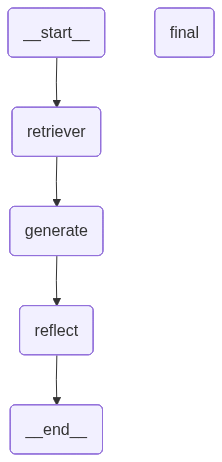

In [16]:
from IPython.display import Image, display

display(Image(Reflection_RAG.get_graph().draw_mermaid_png()))

In [18]:
query = 'what are the additional experiments in Transformers evaluation?'
state = ReflectionState(question=query)
results = Reflection_RAG.invoke(state)

print(f"Answer: \n{results['answer']}")
print(f"Reflection log: \n{results['reflection']}")
print(f"Total Attempts: \n{results['attempts']}")

Answer: 
The additional experiments in the Transformers evaluation are:

1. **FlashAttention2**:
   - Integrated into LLaMA2.
   - Reduces context latency by approximately 50%.

2. **Chain-of-Thought prompting**:
   - Outperforms direct answer prompting by 8% on logic tasks.
   - Reflective prompting increases accuracy by 3%.

3. **Tool-augmented prompting**:
   - Integrates LangGraph, Wikipedia, and SQL search.
   - Enables dynamic retrieval-agent reasoning.
   - Example: "Give me customer insights from SQL, verify with wiki."

4. **Human evaluation protocol**:
   - Internal annotators score fluency, helpfulness, and correctness.
   - GPT-4 used as a synthetic evaluator.

5. **Retrieval experiments**:
   - Hybrid dense + sparse retriever tested.
   - Comparison of Weaviate vs. FAISS + BM25 reranking.
   - FAISS is more efficient but has slightly lower recall.
   - Weaviate integration with GraphQL is helpful for filtering.

6. **LoRA tuning**:
   - Used for adapter-based fine-tuning.
